 # 03 — FPCA vs FPLS on L2-Normalised Sampled Spectra



 This notebook compares two functional dimension-reduction strategies for

 Gaia XP sampled spectra:



 - FPCA: unsupervised projection based on the main directions of spectral

   variation.

 - FPLS: supervised projection based on directions that are related to the

   binary/non-binary label.



 The same repeated stratified splits are used for all methods, so the

 comparison is fair across representation types, component numbers, and

 classifiers.



 Main outputs:



 - fold-level model metrics;

 - aggregated summary tables;

 - best model tables;

 - thesis-ready SVG figures.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")



 ## 1. General configuration



 This section defines the experiment settings. These values control the random

 seed, the tested number of components, the number of neighbours for kNN, and

 whether the notebook should run in full mode or quick test mode.

In [2]:
# Fixed random seed for reproducible random operations.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Number of FPCA/FPLS components tested in the experiment.
J_VALUES = [1, 2, 3, 5, 10, 15, 20, 30]

# Number of neighbours used by the kNN and weighted kNN classifiers.
K_KNN = 5

# If True, only the first repeated CV block is used.
# This is useful for quick testing before running the full experiment.
SMOKE = False

# Classifiers evaluated on the FPCA and FPLS score representations.
CLASSIFIERS = [
    "centroid",
    "knn",
    "weighted_knn",
    "lr",
    "linear_svm",
]



 ## 2. Paths and input files



 The notebook expects all input data to be stored in the `og_data` directory.

 The output tables and figures are saved to the `results/03_fpca_vs_fpls`

 directory.



 Required files:



 - `og_xp.csv`: object labels;

 - `xp_sampled_spectra.csv`: sampled Gaia XP spectra;

 - `splits_rskf.json`: predefined repeated stratified cross-validation splits.

In [3]:
BASE_DIR = Path.cwd() / "og_data"
OUT_DIR = Path.cwd() / "results" / "03_fpca_vs_fpls"
OUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_CANDIDATES = [
    BASE_DIR / "og_xp.csv",
]

SAMPLED_CANDIDATES = [
    BASE_DIR / "xp_sampled_spectra.csv",
]

SPLITS_CANDIDATES = [
    BASE_DIR / "splits_rskf.json",
]



 ## 3. Plot style



 This section defines a consistent thesis-ready visual style. FPCA models use

 a blue color family, while FPLS models use a burgundy/red color family.

In [4]:
COLOR_PRIMARY = "#104A7E"
COLOR_SECONDARY = "#414141"
COLOR_DARK = "#0D1530"
COLOR_LIGHT = "#D9D9D9"
COLOR_TEXT = "#222222"

PLOT_COLORS = {
    ("FPCA", "centroid"): "#6DCDF4",
    ("FPCA", "knn"): "#4FAFD8",
    ("FPCA", "weighted_knn"): "#2E8FB8",
    ("FPCA", "lr"): "#104A7E",
    ("FPCA", "linear_svm"): "#0D1530",
    ("FPLS", "centroid"): "#F06E92",
    ("FPLS", "knn"): "#D9577D",
    ("FPLS", "weighted_knn"): "#B63F65",
    ("FPLS", "lr"): "#78003F",
    ("FPLS", "linear_svm"): "#4A0028",
}

PLOT_LABELS = {
    ("FPCA", "centroid"): "FPCA + centroidas",
    ("FPCA", "knn"): "FPCA + kNN",
    ("FPCA", "weighted_knn"): "FPCA + svorinis kNN",
    ("FPCA", "lr"): "FPCA + logistinė regresija",
    ("FPCA", "linear_svm"): "FPCA + tiesinis SVM",
    ("FPLS", "centroid"): "FPLS + centroidas",
    ("FPLS", "knn"): "FPLS + kNN",
    ("FPLS", "weighted_knn"): "FPLS + svorinis kNN",
    ("FPLS", "lr"): "FPLS + logistinė regresija",
    ("FPLS", "linear_svm"): "FPLS + tiesinis SVM",
}

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "axes.edgecolor": "#444444",
        "axes.linewidth": 0.8,
        "axes.labelcolor": COLOR_TEXT,
        "xtick.color": COLOR_TEXT,
        "ytick.color": COLOR_TEXT,
        "text.color": COLOR_TEXT,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)



 ## 4. Helper functions



 The helper functions below keep the notebook shorter and make the experiment

 easier to reuse. Each function has a short docstring explaining its role.

In [5]:
def apply_clean_axes(ax, add_grid: bool = False, grid_axis: str = "y") -> None:
    """Apply minimal thesis-style formatting to a matplotlib axis.

    The function removes the top and right plot borders. It can also add a
    light dashed grid along a selected axis.

    Parameters
    ----------
    ax:
        Matplotlib axis object that should be formatted.
    add_grid:
        Whether to add a light dashed grid.
    grid_axis:
        Axis along which the grid is drawn. Usually `"y"` or `"both"`.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if add_grid:
        ax.grid(
            True,
            axis=grid_axis,
            linestyle="--",
            linewidth=0.6,
            alpha=0.5,
            color=COLOR_LIGHT,
        )
    else:
        ax.grid(False)


def show_and_save(fig, path: Path) -> None:
    """Show a figure and save it as an SVG file.

    The figure is saved immediately after the `plt.show()` call, so the figure
    export stays next to the plotting code instead of being repeated later in a
    separate save section.

    Parameters
    ----------
    fig:
        Matplotlib figure object to save.
    path:
        Output path for the SVG figure.
    """
    plt.tight_layout()
    plt.show()
    fig.savefig(path, format="svg", bbox_inches="tight", facecolor="white")
    plt.close(fig)


def find_first_existing(candidates: Sequence[Path]) -> Path | None:
    """Return the first existing path from a list of candidate paths.

    Parameters
    ----------
    candidates:
        Possible file paths to check.

    Returns
    -------
    Path | None
        First path that exists, or `None` if no candidate exists.
    """
    for path in candidates:
        if path.exists():
            return path

    return None


def split_sort_key(split_name: str) -> tuple[int, int]:
    """Sort split names by repetition and fold number.

    The expected split name format is similar to `rep0_fold0`.

    Parameters
    ----------
    split_name:
        Name of one cross-validation split.

    Returns
    -------
    tuple[int, int]
        Parsed repetition number and fold number.
    """
    rep = int(split_name.split("_")[0].replace("rep", ""))
    fold = int(split_name.split("_")[1].replace("fold", ""))

    return rep, fold


def mean_std_string(mean: float, std: float) -> str | float:
    """Format mean and standard deviation as a compact string.

    Parameters
    ----------
    mean:
        Mean metric value.
    std:
        Standard deviation of the metric.

    Returns
    -------
    str | float
        Formatted string, or `np.nan` if the mean is missing.
    """
    if pd.isna(mean):
        return np.nan

    std_value = 0.0 if pd.isna(std) else std
    return f"{mean:.4f} ± {std_value:.4f}"


def normalize_scores_train_ref(
    scores_te: np.ndarray,
    scores_tr: np.ndarray,
) -> np.ndarray:
    """Normalize test scores using the training-score range.

    This keeps thresholding consistent because the test scores are transformed
    using only information available from the training fold.

    Parameters
    ----------
    scores_te:
        Scores to normalize.
    scores_tr:
        Training scores used as the reference range.

    Returns
    -------
    np.ndarray
        Scores scaled to the interval `[0, 1]`.
    """
    lo = float(scores_tr.min())
    hi = float(scores_tr.max())

    if hi == lo:
        return np.full_like(scores_te, 0.5, dtype=np.float64)

    normalized = ((scores_te - lo) / (hi - lo)).astype(np.float64)
    return np.clip(normalized, 0.0, 1.0)


def pick_youden_threshold(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    grid_size: int = 200,
) -> float:
    """Choose a classification threshold by maximizing Youden's J statistic.

    Youden's J is defined as sensitivity + specificity - 1. The threshold is
    selected on the training fold and later applied to the test fold.

    Parameters
    ----------
    y_true:
        True binary labels.
    y_prob:
        Normalized scores or probabilities.
    grid_size:
        Number of candidate thresholds between 0 and 1.

    Returns
    -------
    float
        Best threshold according to Youden's J statistic.
    """
    thresholds = np.linspace(0, 1, grid_size)
    best_j = -1.0
    best_threshold = 0.5

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1],
        ).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
        specificity = tn / (tn + fp) if (tn + fp) else 0.0
        youden_j = sensitivity + specificity - 1.0

        if youden_j > best_j:
            best_j = youden_j
            best_threshold = float(threshold)

    return best_threshold


def fold_metrics(
    y_true_te: np.ndarray,
    y_score_te: np.ndarray,
    y_true_tr: np.ndarray,
    y_score_tr: np.ndarray,
) -> dict[str, float]:
    """Calculate all fold-level classification metrics.

    PR-AUC and ROC-AUC are calculated directly from continuous scores.
    Binary metrics are calculated after selecting a Youden threshold on the
    training fold.

    Parameters
    ----------
    y_true_te:
        True labels for the test fold.
    y_score_te:
        Continuous model scores for the test fold.
    y_true_tr:
        True labels for the training fold.
    y_score_tr:
        Continuous model scores for the training fold.

    Returns
    -------
    dict[str, float]
        Fold-level metrics.
    """
    metrics = {
        "pr_auc": average_precision_score(y_true_te, y_score_te),
    }

    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true_te, y_score_te))
    except ValueError:
        metrics["roc_auc"] = np.nan

    prob_tr = normalize_scores_train_ref(y_score_tr, y_score_tr)
    prob_te = normalize_scores_train_ref(y_score_te, y_score_tr)

    threshold = pick_youden_threshold(y_true_tr, prob_tr)
    y_pred = (prob_te >= threshold).astype(np.int64)

    metrics["youden_threshold"] = threshold
    metrics["sensitivity"] = recall_score(
        y_true_te,
        y_pred,
        pos_label=1,
        zero_division=0,
    )
    metrics["precision"] = precision_score(
        y_true_te,
        y_pred,
        pos_label=1,
        zero_division=0,
    )
    metrics["specificity"] = recall_score(
        y_true_te,
        y_pred,
        pos_label=0,
        zero_division=0,
    )
    metrics["accuracy"] = accuracy_score(y_true_te, y_pred)
    metrics["f1"] = f1_score(
        y_true_te,
        y_pred,
        pos_label=1,
        zero_division=0,
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true_te,
        y_pred,
        labels=[0, 1],
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    metrics["youden_j"] = sensitivity + specificity - 1.0

    return metrics


def projection_fpca(
    spectra_train_centered: np.ndarray,
    spectra_test_centered: np.ndarray,
    n_components: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Project spectra into an FPCA score space.

    PCA is used here as the discrete implementation of FPCA on sampled spectra.

    Parameters
    ----------
    spectra_train_centered:
        Mean-centered training spectra.
    spectra_test_centered:
        Mean-centered test spectra.
    n_components:
        Number of FPCA components.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Training and test FPCA scores.
    """
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    train_scores = pca.fit_transform(spectra_train_centered)
    test_scores = pca.transform(spectra_test_centered)

    return train_scores, test_scores


def projection_fpls(
    spectra_train_centered: np.ndarray,
    spectra_test_centered: np.ndarray,
    y_train: np.ndarray,
    n_components: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Project spectra into an FPLS score space.

    FPLS is implemented using partial least squares regression. Unlike FPCA,
    this projection uses class-label information during training.

    Parameters
    ----------
    spectra_train_centered:
        Mean-centered training spectra.
    spectra_test_centered:
        Mean-centered test spectra.
    y_train:
        Training labels used by the supervised FPLS projection.
    n_components:
        Number of FPLS components.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Training and test FPLS scores.
    """
    pls = PLSRegression(n_components=n_components)
    pls.fit(spectra_train_centered, y_train)

    train_scores = pls.transform(spectra_train_centered)
    test_scores = pls.transform(spectra_test_centered)

    return train_scores, test_scores


def centroid_scores(
    train_scores: np.ndarray,
    y_train: np.ndarray,
    test_scores: np.ndarray,
) -> np.ndarray:
    """Calculate centroid-based classification scores.

    The score is positive when an object is closer to the binary-class centroid
    than to the non-binary-class centroid.

    Parameters
    ----------
    train_scores:
        Training observations in the projected score space.
    y_train:
        Training labels.
    test_scores:
        Observations to score.

    Returns
    -------
    np.ndarray
        Continuous centroid scores.
    """
    binary_centroid = train_scores[y_train == 1].mean(axis=0)
    non_binary_centroid = train_scores[y_train == 0].mean(axis=0)

    distance_to_non_binary = np.sum(
        (test_scores - non_binary_centroid) ** 2,
        axis=1,
    )
    distance_to_binary = np.sum(
        (test_scores - binary_centroid) ** 2,
        axis=1,
    )

    return distance_to_non_binary - distance_to_binary


def knn_scores(
    train_scores: np.ndarray,
    y_train: np.ndarray,
    test_scores: np.ndarray,
    k: int = 5,
    weighted: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    """Calculate kNN or weighted kNN scores.

    Test scores are calculated from the nearest training neighbours. Training
    scores are calculated with leave-one-out logic, so the object itself is not
    used as its own nearest neighbour.

    Parameters
    ----------
    train_scores:
        Training observations in the projected score space.
    y_train:
        Training labels.
    test_scores:
        Test observations in the projected score space.
    k:
        Number of nearest neighbours.
    weighted:
        If True, closer neighbours receive larger inverse-distance weights.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Training and test kNN scores.
    """
    nearest_test = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nearest_test.fit(train_scores)

    distances_test, indices_test = nearest_test.kneighbors(test_scores)
    labels_test_neighbors = y_train[indices_test]

    if weighted:
        weights_test = 1.0 / np.maximum(distances_test, 1e-12)
        score_test = (
            weights_test * labels_test_neighbors
        ).sum(axis=1) / weights_test.sum(axis=1)
    else:
        score_test = labels_test_neighbors.mean(axis=1)

    # For training scores, use k + 1 neighbours and remove the first neighbour,
    # because the closest point to each training observation is itself.
    nearest_train = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
    nearest_train.fit(train_scores)

    distances_train, indices_train = nearest_train.kneighbors(train_scores)

    distances_train = distances_train[:, 1:]
    indices_train = indices_train[:, 1:]
    labels_train_neighbors = y_train[indices_train]

    if weighted:
        weights_train = 1.0 / np.maximum(distances_train, 1e-12)
        score_train = (
            weights_train * labels_train_neighbors
        ).sum(axis=1) / weights_train.sum(axis=1)
    else:
        score_train = labels_train_neighbors.mean(axis=1)

    return score_train.astype(np.float64), score_test.astype(np.float64)


def summarise_run(
    df_run: pd.DataFrame,
    group_cols: list[str],
) -> pd.DataFrame:
    """Summarise fold-level results by selected grouping columns.

    Parameters
    ----------
    df_run:
        Fold-level metric table.
    group_cols:
        Columns used for grouping, for example representation, classifier,
        and number of components.

    Returns
    -------
    pd.DataFrame
        Aggregated table with metric means and standard deviations.
    """
    metric_cols = [
        "pr_auc",
        "roc_auc",
        "sensitivity",
        "precision",
        "specificity",
        "accuracy",
        "f1",
        "youden_j",
        "youden_threshold",
    ]

    agg_dict = {}

    for metric in metric_cols:
        agg_dict[f"{metric}_mean"] = pd.NamedAgg(
            column=metric,
            aggfunc="mean",
        )
        agg_dict[f"{metric}_std"] = pd.NamedAgg(
            column=metric,
            aggfunc="std",
        )

    return df_run.groupby(group_cols).agg(**agg_dict).reset_index()


def make_best_models_table(df_agg: pd.DataFrame) -> pd.DataFrame:
    """Create a compact table of best models.

    The table includes the best model by representation family and the best
    model within each classifier type.

    Parameters
    ----------
    df_agg:
        Aggregated metric table.

    Returns
    -------
    pd.DataFrame
        Best-model summary table.
    """
    best_by_representation = (
        df_agg.sort_values(
            ["method_family", "f1_mean", "pr_auc_mean"],
            ascending=[True, False, False],
        )
        .groupby("method_family", as_index=False)
        .first()
    )

    best_by_classifier = (
        df_agg.sort_values(
            ["classifier", "f1_mean", "pr_auc_mean"],
            ascending=[True, False, False],
        )
        .groupby("classifier", as_index=False)
        .first()
    )

    best_by_representation["selection_type"] = "best_by_representation"
    best_by_representation["selection_name"] = (
        best_by_representation["method_family"]
    )

    best_by_classifier["selection_type"] = "best_by_classifier"
    best_by_classifier["selection_name"] = best_by_classifier["classifier"]

    keep_cols = [
        "selection_type",
        "selection_name",
        "method_family",
        "classifier",
        "J",
        "pr_auc_mean",
        "pr_auc_std",
        "roc_auc_mean",
        "roc_auc_std",
        "f1_mean",
        "f1_std",
    ]

    return pd.concat(
        [
            best_by_representation[keep_cols],
            best_by_classifier[keep_cols],
        ],
        ignore_index=True,
    )


def plot_metric_vs_j(
    df_run: pd.DataFrame,
    metric_key: str,
    ylabel: str,
    output_path: Path,
) -> None:
    """Plot one performance metric against the number of components.

    The plot shows mean performance across splits and a shaded interval of
    ±1 standard deviation.

    Parameters
    ----------
    df_run:
        Fold-level metric table.
    metric_key:
        Metric column to plot, for example `"pr_auc"` or `"f1"`.
    ylabel:
        Label used for the y-axis.
    output_path:
        Path where the SVG figure is saved.
    """
    fig, ax = plt.subplots(figsize=(11, 6))

    for family in ["FPCA", "FPLS"]:
        for classifier in CLASSIFIERS:
            subset = df_run[
                (df_run["method_family"] == family)
                & (df_run["classifier"] == classifier)
            ]

            metric_mean = subset.groupby("J")[metric_key].mean().reindex(
                J_VALUES,
            )
            metric_std = subset.groupby("J")[metric_key].std().reindex(
                J_VALUES,
            )

            mean_values = metric_mean.values
            std_values = metric_std.values

            ax.plot(
                J_VALUES,
                mean_values,
                "o-",
                color=PLOT_COLORS[(family, classifier)],
                label=PLOT_LABELS[(family, classifier)],
                ms=4,
                linewidth=1.8,
            )

            ax.fill_between(
                J_VALUES,
                mean_values - std_values,
                mean_values + std_values,
                color=PLOT_COLORS[(family, classifier)],
                alpha=0.10,
            )

    ax.set_xlabel("Komponenčių skaičius, J")
    ax.set_ylabel(ylabel)
    ax.set_xticks(J_VALUES)
    ax.legend(loc="best", fontsize=8, ncol=2, frameon=False)
    apply_clean_axes(ax, add_grid=True, grid_axis="y")

    show_and_save(fig, output_path)



 ## 5. Load sampled spectra, labels, and predefined splits



 The label file and sampled spectra file are merged by `source_id`. The code

 assumes one-to-one alignment between both files.

In [6]:
og_path = find_first_existing(LABEL_CANDIDATES)
spec_path = find_first_existing(SAMPLED_CANDIDATES)
split_path = find_first_existing(SPLITS_CANDIDATES)

if og_path is None:
    raise FileNotFoundError(
        "Could not find `og_xp.csv`. "
        f"Checked: {[str(path) for path in LABEL_CANDIDATES]}"
    )

if spec_path is None:
    raise FileNotFoundError(
        "Could not find `xp_sampled_spectra.csv`. "
        f"Checked: {[str(path) for path in SAMPLED_CANDIDATES]}"
    )

if split_path is None:
    raise FileNotFoundError(
        "Could not find `splits_rskf.json`. "
        f"Checked: {[str(path) for path in SPLITS_CANDIDATES]}"
    )

print("Using label file:", og_path.resolve())
print("Using sampled spectra file:", spec_path.resolve())
print("Using split file:", split_path.resolve())

df_og = pd.read_csv(og_path)
df_spec = pd.read_csv(spec_path)

if "source_id" not in df_og.columns or "y" not in df_og.columns:
    raise ValueError("Label file must contain `source_id` and `y`.")

if "source_id" not in df_spec.columns:
    raise ValueError("Sampled spectra file must contain `source_id`.")

# Spectral flux columns are expected to be named like wl_336, wl_338, etc.
wl_cols = [col for col in df_spec.columns if col.startswith("wl_")]

if len(wl_cols) == 0:
    raise ValueError("No wavelength columns found. Expected columns `wl_*`.")

wavelengths = np.array(
    [float(col.split("_")[1]) for col in wl_cols],
    dtype=np.float64,
)

df_m = df_og[["source_id", "y"]].merge(
    df_spec[["source_id"] + wl_cols],
    on="source_id",
    how="inner",
    validate="one_to_one",
)

assert len(df_m) == len(df_og) == len(df_spec), "Row alignment failed."

y = df_m["y"].to_numpy(dtype=np.int64)
spectra_raw = df_m[wl_cols].to_numpy(dtype=np.float64)

n_objects, n_wavelengths = spectra_raw.shape

print(f"N = {n_objects}, p = {n_wavelengths} wavelength bins")
print(
    "Class balance: "
    f"nedvinarės={int((y == 0).sum())}, "
    f"dvinarės={int((y == 1).sum())} "
    f"({(y == 1).mean():.1%} positive)"
)



Using label file: C:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\og_data\og_xp.csv
Using sampled spectra file: C:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\og_data\xp_sampled_spectra.csv
Using split file: C:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\og_data\splits_rskf.json
N = 2815, p = 343 wavelength bins
Class balance: nedvinarės=2257, dvinarės=558 (19.8% positive)


 ## 6. L2 normalisation



 Each spectrum is divided by its L2 norm. This keeps the comparison focused on

 spectral shape rather than total flux scale.

In [7]:
norms = np.linalg.norm(spectra_raw, axis=1, keepdims=True)
norms = np.maximum(norms, 1e-15)

spectra_l2 = spectra_raw / norms



 ## 7. Quick diagnostic: class mean difference



 This plot shows the wavelength-wise difference between the binary and

 non-binary mean spectra after L2 normalisation.

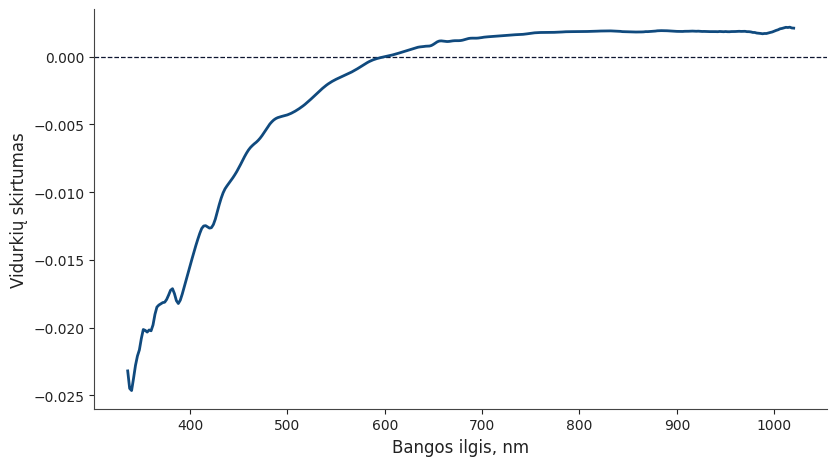

In [8]:
mean_non_binary = spectra_l2[y == 0].mean(axis=0)
mean_binary = spectra_l2[y == 1].mean(axis=0)
mean_difference = mean_binary - mean_non_binary

fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.axhline(0, color=COLOR_DARK, lw=0.9, linestyle="--")
ax.plot(wavelengths, mean_difference, lw=2.0, color=COLOR_PRIMARY)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidurkių skirtumas")

apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_mean_shape_difference.svg")



 ## 8. Load repeated stratified cross-validation splits



 These predefined splits are reused for every method. This makes the

 comparison paired and directly comparable across models.

In [9]:
with open(split_path, encoding="utf-8") as file:
    splits = json.load(file)

if SMOKE:
    splits = {
        split_name: split_value
        for split_name, split_value in splits.items()
        if split_name.startswith("rep0_")
    }
    print(f"SMOKE mode: using {len(splits)} splits")
else:
    print(f"Full mode: using {len(splits)} splits")

split_names = sorted(splits.keys(), key=split_sort_key)

print(f"Loaded {len(split_names)} splits")



Full mode: using 50 splits
Loaded 50 splits


 ## 9. Run FPCA and FPLS experiments



 For each split and each value of `J`, both FPCA and FPLS projections are

 fitted only on the training fold. Classifiers are then trained and evaluated

 in the corresponding score space.

In [10]:
records = []

print(f"--- Starting evaluation for {len(split_names)} splits ---")

for split_name in split_names:
    print(f"\nProcessing split: {split_name}")

    train_idx = np.array(splits[split_name]["train"], dtype=int)
    test_idx = np.array(splits[split_name]["test"], dtype=int)

    spectra_train = spectra_l2[train_idx]
    spectra_test = spectra_l2[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    # Mean-centering is fitted on the training fold only.
    train_mean = spectra_train.mean(axis=0)
    spectra_train_centered = spectra_train - train_mean
    spectra_test_centered = spectra_test - train_mean

    max_allowed_j = min(
        spectra_train_centered.shape[0] - 1,
        spectra_train_centered.shape[1],
    )

    for n_components in J_VALUES:
        if n_components > max_allowed_j:
            continue

        print(f"  > J={n_components}: FPCA + FPLS")

        for method_family in ["FPCA", "FPLS"]:
            if method_family == "FPCA":
                train_scores, test_scores = projection_fpca(
                    spectra_train_centered,
                    spectra_test_centered,
                    n_components,
                )
            else:
                train_scores, test_scores = projection_fpls(
                    spectra_train_centered,
                    spectra_test_centered,
                    y_train,
                    n_components,
                )

            # Centroid classifier.
            score_train = centroid_scores(
                train_scores,
                y_train,
                train_scores,
            )
            score_test = centroid_scores(
                train_scores,
                y_train,
                test_scores,
            )
            metrics = fold_metrics(
                y_test,
                score_test,
                y_train,
                score_train,
            )
            records.append(
                {
                    "split": split_name,
                    "method_family": method_family,
                    "J": n_components,
                    "classifier": "centroid",
                    **metrics,
                }
            )

            # Unweighted kNN classifier.
            score_train, score_test = knn_scores(
                train_scores,
                y_train,
                test_scores,
                k=K_KNN,
                weighted=False,
            )
            metrics = fold_metrics(
                y_test,
                score_test,
                y_train,
                score_train,
            )
            records.append(
                {
                    "split": split_name,
                    "method_family": method_family,
                    "J": n_components,
                    "classifier": "knn",
                    **metrics,
                }
            )

            # Weighted kNN classifier.
            score_train, score_test = knn_scores(
                train_scores,
                y_train,
                test_scores,
                k=K_KNN,
                weighted=True,
            )
            metrics = fold_metrics(
                y_test,
                score_test,
                y_train,
                score_train,
            )
            records.append(
                {
                    "split": split_name,
                    "method_family": method_family,
                    "J": n_components,
                    "classifier": "weighted_knn",
                    **metrics,
                }
            )

            # Logistic regression on FPCA/FPLS scores.
            lr_model = LogisticRegression(
                class_weight="balanced",
                max_iter=5000,
                random_state=RANDOM_STATE,
            )
            lr_model.fit(train_scores, y_train)

            score_train = lr_model.decision_function(train_scores)
            score_test = lr_model.decision_function(test_scores)

            metrics = fold_metrics(
                y_test,
                score_test,
                y_train,
                score_train,
            )
            records.append(
                {
                    "split": split_name,
                    "method_family": method_family,
                    "J": n_components,
                    "classifier": "lr",
                    **metrics,
                }
            )

            # Linear SVM on FPCA/FPLS scores.
            svm_model = LinearSVC(
                C=1.0,
                class_weight="balanced",
                max_iter=10000,
                random_state=RANDOM_STATE,
            )
            svm_model.fit(train_scores, y_train)

            score_train = svm_model.decision_function(train_scores)
            score_test = svm_model.decision_function(test_scores)

            metrics = fold_metrics(
                y_test,
                score_test,
                y_train,
                score_train,
            )
            records.append(
                {
                    "split": split_name,
                    "method_family": method_family,
                    "J": n_components,
                    "classifier": "linear_svm",
                    **metrics,
                }
            )

print("\n--- All evaluations finished ---")

df_run = pd.DataFrame(records)
display(df_run.head())



--- Starting evaluation for 50 splits ---

Processing split: rep0_fold0
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA + FPLS
  > J=20: FPCA + FPLS
  > J=30: FPCA + FPLS

Processing split: rep0_fold1
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA + FPLS
  > J=20: FPCA + FPLS
  > J=30: FPCA + FPLS

Processing split: rep0_fold2
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA + FPLS
  > J=20: FPCA + FPLS
  > J=30: FPCA + FPLS

Processing split: rep0_fold3
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA + FPLS
  > J=20: FPCA + FPLS
  > J=30: FPCA + FPLS

Processing split: rep0_fold4
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA

,split,method_family,J,classifier,pr_auc,roc_auc,youden_threshold,sensitivity,precision,specificity,accuracy,f1,youden_j
0,rep0_fold0,FPCA,1,centroid,0.292695,0.640457,0.010050,0.819820,0.259259,0.424779,0.502664,0.393939,0.244599
1,rep0_fold0,FPCA,1,knn,0.214514,0.524436,0.005025,0.648649,0.211144,0.404867,0.452931,0.318584,0.053516
2,rep0_fold0,FPCA,1,weighted_knn,0.221288,0.521038,0.115578,0.468468,0.192593,0.517699,0.507993,0.272966,-0.013832
3,rep0_fold0,FPCA,1,lr,0.292695,0.640457,0.010050,0.819820,0.259259,0.424779,0.502664,0.393939,0.244599
4,rep0_fold0,FPCA,1,linear_svm,0.292695,0.640457,0.010050,0.819820,0.259259,0.424779,0.502664,0.393939,0.244599


 ## 10. Summary tables



 The fold-level results are aggregated by representation type, classifier,

 and component number. The main ranking uses F1 first, then PR-AUC and ROC-AUC.

In [11]:
df_agg = summarise_run(
    df_run,
    ["method_family", "J", "classifier"],
)

best_models_df = make_best_models_table(df_agg)

display_method_names = {
    "FPCA": "FPCA",
    "FPLS": "FPLS",
}

rank_by_f1 = df_agg.sort_values(
    ["f1_mean", "pr_auc_mean", "roc_auc_mean"],
    ascending=False,
).reset_index(drop=True)

rank_by_f1_display = rank_by_f1.copy()
rank_by_f1_display["method_family"] = rank_by_f1_display[
    "method_family"
].map(display_method_names)

print("\n=== TOP 15 BY F1 ===")
display(
    rank_by_f1_display[
        [
            "method_family",
            "J",
            "classifier",
            "f1_mean",
            "pr_auc_mean",
            "roc_auc_mean",
        ]
    ].head(15)
)

best_models_display = best_models_df.copy()
best_models_display["method_family"] = best_models_display[
    "method_family"
].map(display_method_names)
best_models_display["selection_name"] = best_models_display[
    "selection_name"
].replace(display_method_names)

print("\n=== BEST MODELS TABLE ===")
display(best_models_display)




=== TOP 15 BY F1 ===


,method_family,J,classifier,f1_mean,pr_auc_mean,roc_auc_mean
0,FPLS,5,linear_svm,0.811313,0.870002,0.931923
1,FPLS,5,lr,0.809099,0.869331,0.931900
2,FPLS,10,lr,0.795228,0.868294,0.932527
3,FPLS,10,linear_svm,0.792565,0.866064,0.931513
4,FPLS,15,lr,0.786889,0.868051,0.934860
5,FPLS,20,lr,0.783136,0.867886,0.934405
6,FPLS,15,linear_svm,0.782889,0.865577,0.933985
7,FPLS,30,lr,0.779961,0.868091,0.934492
8,FPLS,20,linear_svm,0.773825,0.864900,0.933321
9,FPLS,30,linear_svm,0.773543,0.865201,0.933428



=== BEST MODELS TABLE ===


,selection_type,selection_name,method_family,classifier,J,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std
0,best_by_representation,FPCA,FPCA,linear_svm,15,0.656393,0.042532,0.852703,0.019012,0.597005,0.031726
1,best_by_representation,FPLS,FPLS,linear_svm,5,0.870002,0.030436,0.931923,0.014513,0.811313,0.027212
2,best_by_classifier,centroid,FPLS,centroid,3,0.655462,0.045031,0.851376,0.022631,0.584691,0.044648
3,best_by_classifier,knn,FPLS,knn,5,0.768453,0.033866,0.892848,0.016036,0.746743,0.026335
4,best_by_classifier,linear_svm,FPLS,linear_svm,5,0.870002,0.030436,0.931923,0.014513,0.811313,0.027212
5,best_by_classifier,lr,FPLS,lr,5,0.869331,0.030355,0.931900,0.014549,0.809099,0.027177
6,best_by_classifier,weighted_knn,FPLS,weighted_knn,5,0.794761,0.033247,0.894396,0.016256,0.756538,0.030322


 ## 11. PR-AUC and F1 across component numbers



 These plots show how model performance changes as the number of FPCA/FPLS

 components increases.

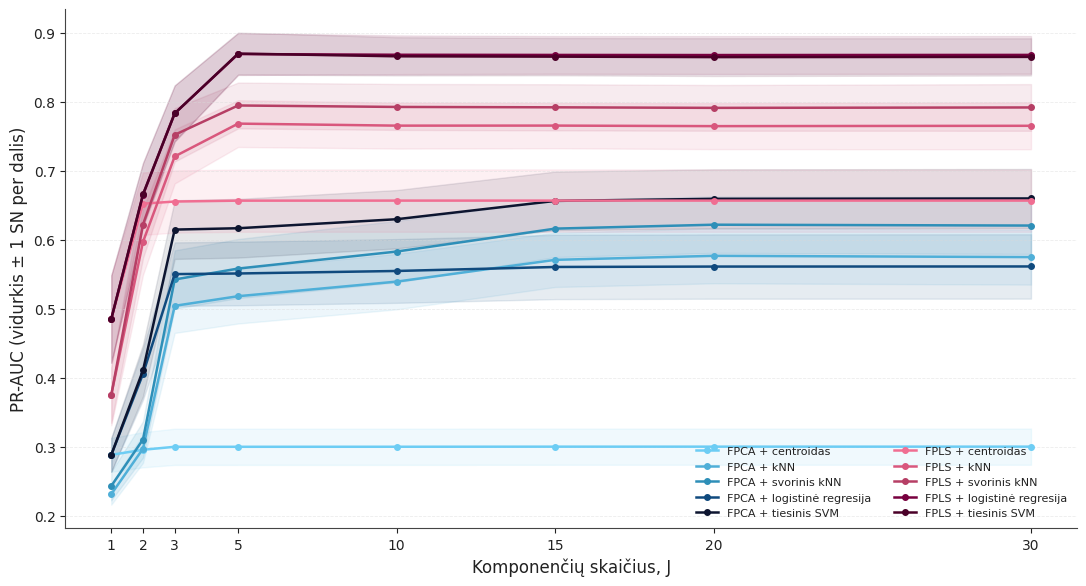

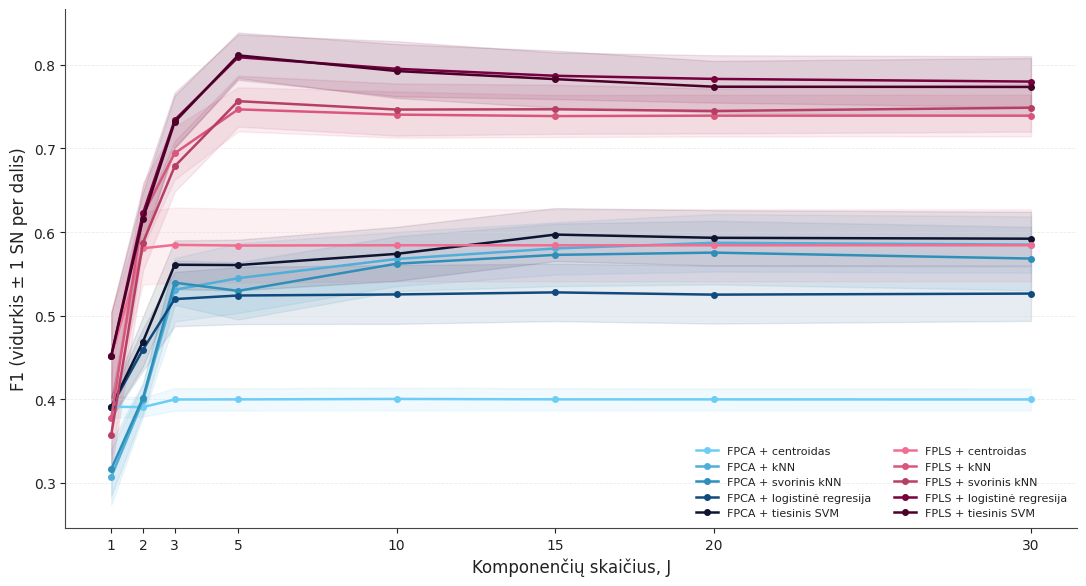

In [12]:
plot_metric_vs_j(
    df_run=df_run,
    metric_key="pr_auc",
    ylabel="PR-AUC (vidurkis ± 1 SN per dalis)",
    output_path=OUT_DIR / "fig_pr_auc_vs_j.svg",
)

plot_metric_vs_j(
    df_run=df_run,
    metric_key="f1",
    ylabel="F1 (vidurkis ± 1 SN per dalis)",
    output_path=OUT_DIR / "fig_f1_vs_j.svg",
)



 ## 12. Best FPCA and best FPLS models



 This section prints the highest-ranked FPCA model and the highest-ranked FPLS

 model according to the main ranking.

In [13]:
fpca_best = rank_by_f1[rank_by_f1["method_family"] == "FPCA"].head(1).copy()
fpls_best = rank_by_f1[rank_by_f1["method_family"] == "FPLS"].head(1).copy()

if len(fpca_best):
    print("\nBest FPCA:")
    display(
        fpca_best[
            [
                "method_family",
                "J",
                "classifier",
                "f1_mean",
                "pr_auc_mean",
                "roc_auc_mean",
            ]
        ]
    )

if len(fpls_best):
    print("\nBest FPLS:")
    display(
        fpls_best[
            [
                "method_family",
                "J",
                "classifier",
                "f1_mean",
                "pr_auc_mean",
                "roc_auc_mean",
            ]
        ]
    )




Best FPCA:


,method_family,J,classifier,f1_mean,pr_auc_mean,roc_auc_mean
27,FPCA,15,linear_svm,0.597005,0.656393,0.852703



Best FPLS:


,method_family,J,classifier,f1_mean,pr_auc_mean,roc_auc_mean
0,FPLS,5,linear_svm,0.811313,0.870002,0.931923


 ## 13. Save main table outputs



 Figure outputs are saved immediately after each plotting block above. This

 section saves only the CSV tables.

In [14]:
df_run.to_csv(
    OUT_DIR / "fpca_fpls_fold_metrics.csv",
    index=False,
)
df_agg.to_csv(
    OUT_DIR / "fpca_fpls_summary.csv",
    index=False,
)
best_models_df.to_csv(
    OUT_DIR / "fpca_fpls_best_models.csv",
    index=False,
)

print("Saved main CSV outputs to:", OUT_DIR)



Saved main CSV outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\03_fpca_vs_fpls


 ## 14. Final quick view



 This final display formats the main best-model metrics as mean ± standard

 deviation for easier inspection.

In [15]:
pretty_best = best_models_df.copy()

pretty_best["PR-AUC"] = [
    mean_std_string(mean, std)
    for mean, std in zip(
        pretty_best["pr_auc_mean"],
        pretty_best["pr_auc_std"],
    )
]

pretty_best["ROC-AUC"] = [
    mean_std_string(mean, std)
    for mean, std in zip(
        pretty_best["roc_auc_mean"],
        pretty_best["roc_auc_std"],
    )
]

pretty_best["F1"] = [
    mean_std_string(mean, std)
    for mean, std in zip(
        pretty_best["f1_mean"],
        pretty_best["f1_std"],
    )
]

display(
    pretty_best[
        [
            "selection_type",
            "selection_name",
            "method_family",
            "classifier",
            "J",
            "PR-AUC",
            "ROC-AUC",
            "F1",
        ]
    ]
)

,selection_type,selection_name,method_family,classifier,J,PR-AUC,ROC-AUC,F1
0,best_by_representation,FPCA,FPCA,linear_svm,15,0.6564 ± 0.0425,0.8527 ± 0.0190,0.5970 ± 0.0317
1,best_by_representation,FPLS,FPLS,linear_svm,5,0.8700 ± 0.0304,0.9319 ± 0.0145,0.8113 ± 0.0272
2,best_by_classifier,centroid,FPLS,centroid,3,0.6555 ± 0.0450,0.8514 ± 0.0226,0.5847 ± 0.0446
3,best_by_classifier,knn,FPLS,knn,5,0.7685 ± 0.0339,0.8928 ± 0.0160,0.7467 ± 0.0263
4,best_by_classifier,linear_svm,FPLS,linear_svm,5,0.8700 ± 0.0304,0.9319 ± 0.0145,0.8113 ± 0.0272
5,best_by_classifier,lr,FPLS,lr,5,0.8693 ± 0.0304,0.9319 ± 0.0145,0.8091 ± 0.0272
6,best_by_classifier,weighted_knn,FPLS,weighted_knn,5,0.7948 ± 0.0332,0.8944 ± 0.0163,0.7565 ± 0.0303
